# Gradient Boost Step by Step Implementation

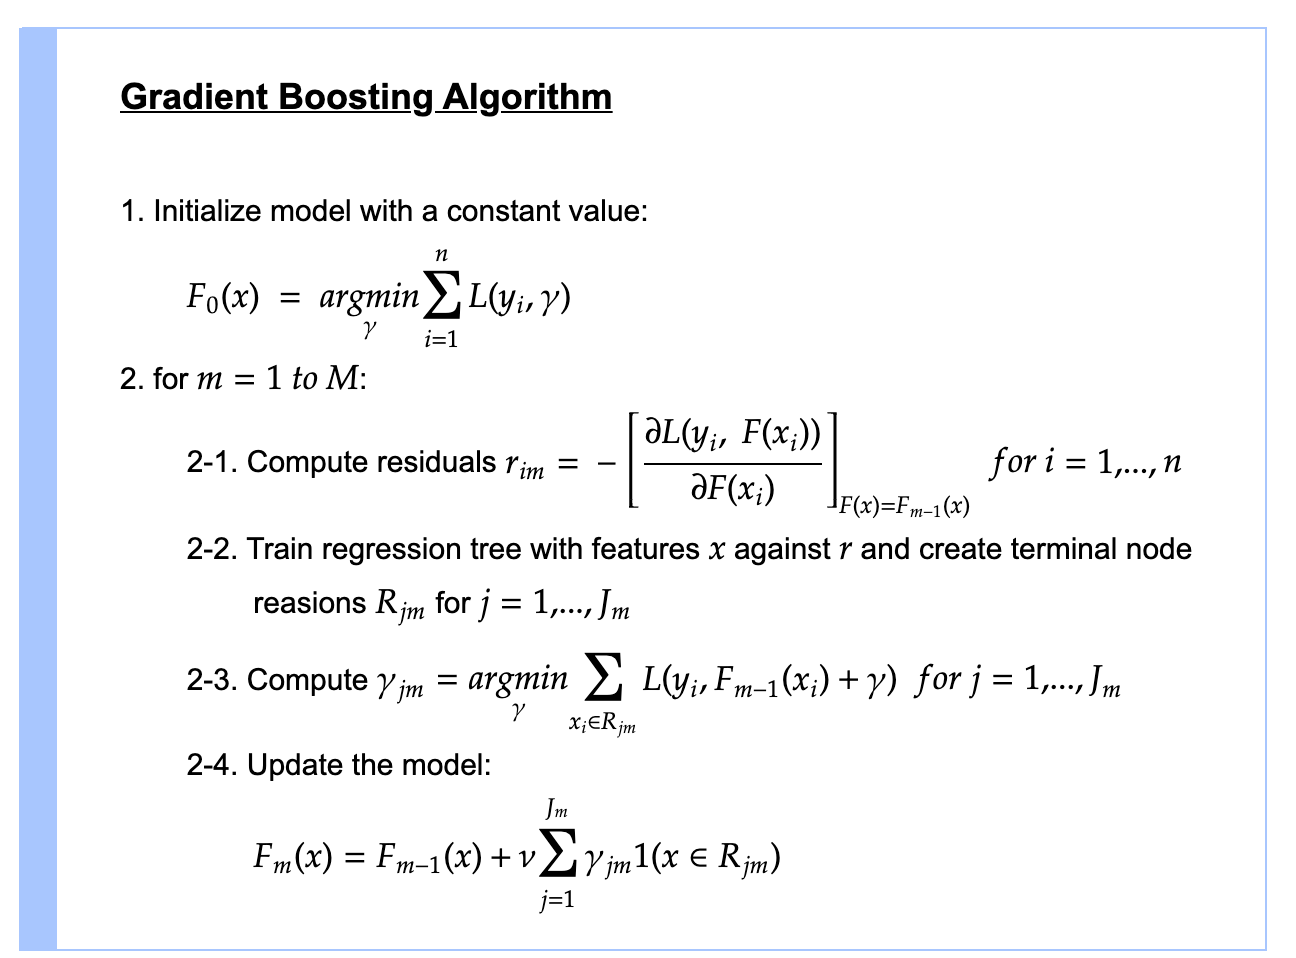

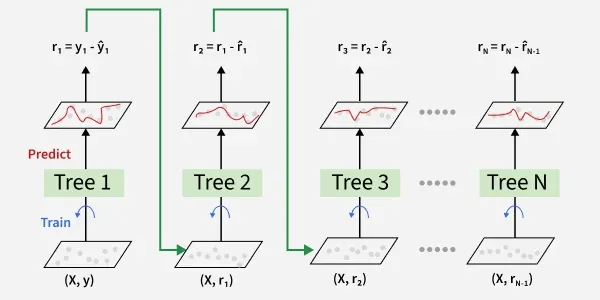

### Importing Libraries

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

### Generating Data

In [128]:
np.random.seed(42)

X=np.random.rand(100,1)-0.5
y=3*X[:,0]**2 + 0.05*np.random.randn(100) # y = 3x² + noise

# np.random.randn(100)

#  This generates 100 random numbers from a standard normal distribution (mean = 0, standard deviation = 1).
# 0.05 * np.random.randn(100): The random values are scaled down: These are called noise.

df=pd.DataFrame(X,columns=['X'])
df['y']=y

df.head()

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986


Why 42 specifically?

There's nothing special about 42 from a programming perspective. It's just a commonly used number because of the science fiction novel The Hitchhiker's Guide to the Galaxy, where 42 is humorously described as "the answer to the ultimate question of life, the universe, and everything."

### Graph : X vs y

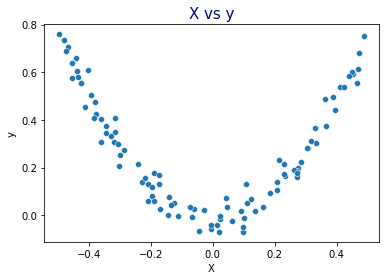

In [129]:
sns.scatterplot(df['X'],df['y']);
plt.title('X vs y',fontsize=15,color='navy');

# Gradient Boost Regression Algorithm Implementation

#### Step 1: Initialize the Algo Model

Initialize the model by predicting the mean of the target variable (y) for every data point. This serves as the initial prediction (base model) before any decision trees are trained.

In [130]:
mean_y=df['y'].mean()
df['pred1']=mean_y
df.head()

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


#### Step 2(a): Calculate the Residuals (Errors)
Residuals are calculated by subtracting the <b>current predictions</b> from the <b>actual target values</b>. 

A residual represents the error made by the current model for each data point.

If the residual is <b>positive</b>, the model has underestimated the target value,
If it is <b>negative</b>, the model has overestimated it.
These residuals indicate how much the predictions need to be corrected and are used as the target values for training the next decision tree.

In [131]:
df['res1']=df['y']-df['pred1']
df.head()

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


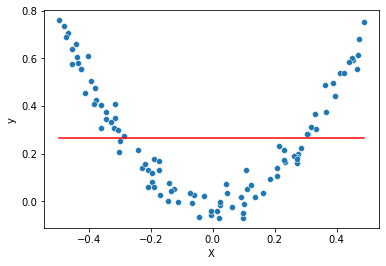

In [132]:
sns.scatterplot(df['X'],df['y'])
sns.lineplot(df['X'],df['pred1'],color='red');

#### Step 2(b): Train a Regression Tree on the Residuals

After calculating the <b>residuals</b>, a regression decision tree is trained using the input features (<b>X</b>) as the <b>input</b> and the residuals (<b>res1</b>) as the <b>target values</b>. 

-> Instead of predicting the original target variable (<b>y</b>), the tree learns the <b>errors</b> made by the current model.
    
-> Its objective is to identify patterns in these residuals so that it can predict the necessary corrections and improve the model's future predictions.

In [133]:
from sklearn.tree import DecisionTreeRegressor

tree1=DecisionTreeRegressor(max_leaf_nodes=8)
tree1.fit(df[['X']],df['res1'])

DecisionTreeRegressor(max_leaf_nodes=8)

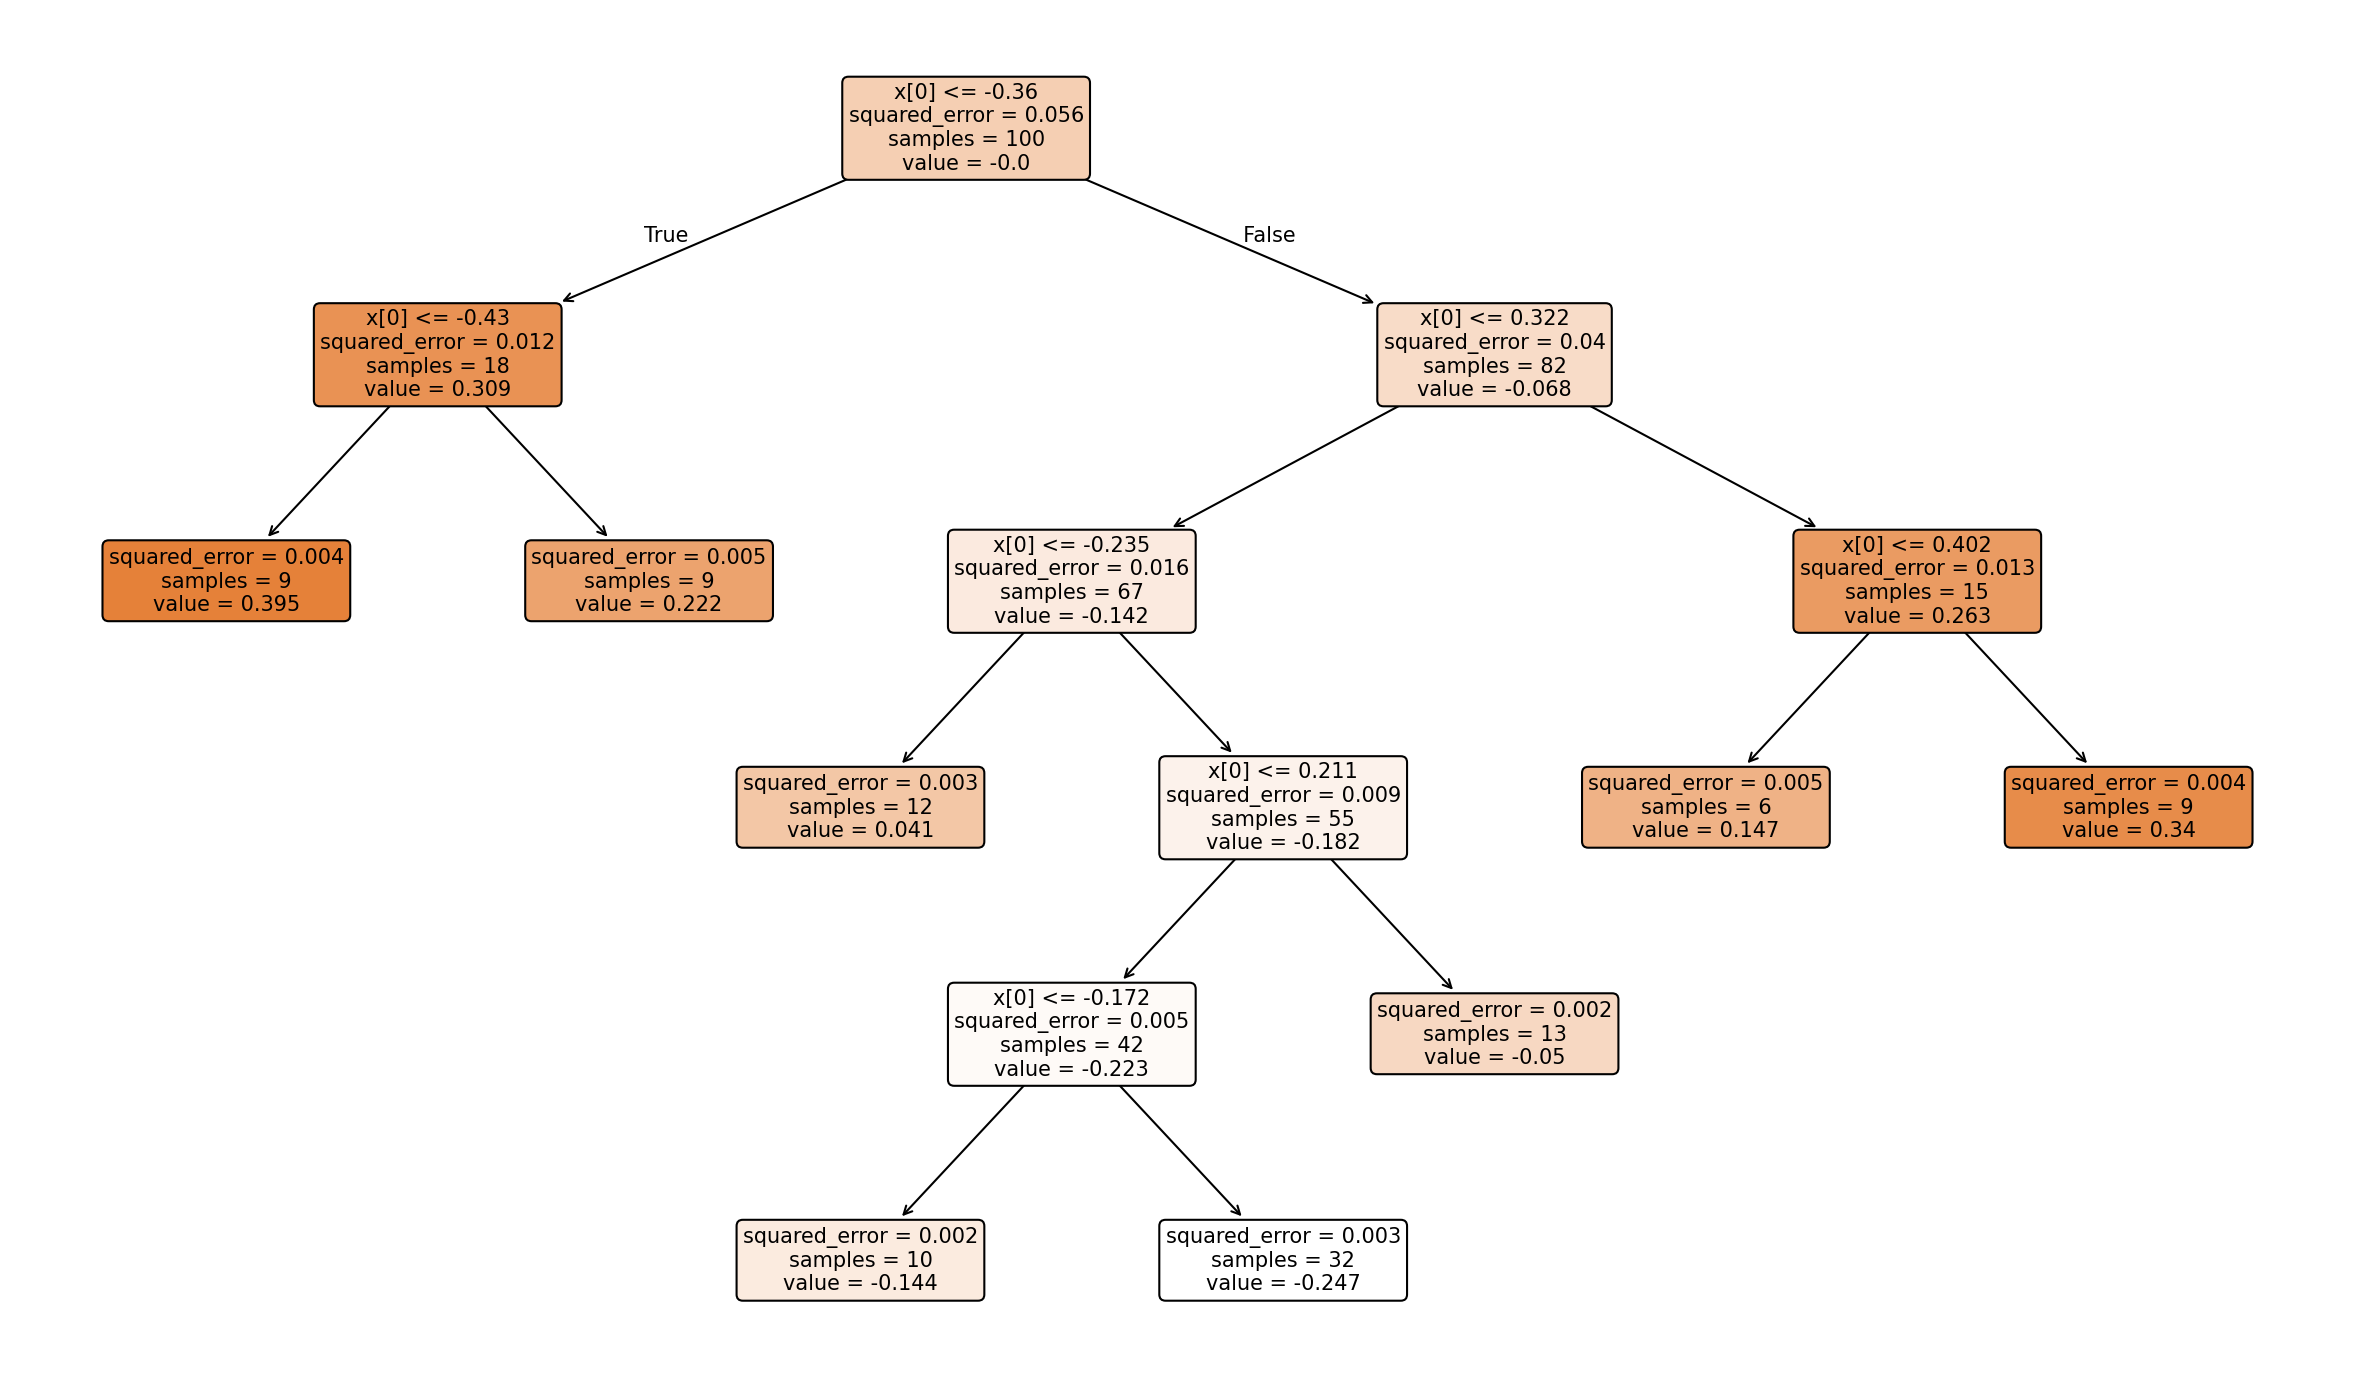

In [134]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,12),dpi=150)
plot_tree(tree1,filled=True,rounded=True,fontsize=10)
plt.show()

#### Step 2(c): Predict the Residuals and Generate Updated Predictions

After training the first regression tree on the <b>residuals</b>, the tree is used to predict the <b>residuals</b> for <b>new input values (X_test)</b>. 

These <b>predicted residuals</b> represent the corrections suggested by the tree.

The corrections are then added to the initial prediction (the mean of the target value) to obtain the updated predictions after the first boosting iteration.

#### Step 2(d): Update the Model Predictions

After the regression tree predicts the <b>residuals</b> for <b>each training sample</b>, these <b>predicted residuals</b> are <b>added</b> to the <b>current predictions</b> to obtain <b>improved predictions</b>.

This updates the model by correcting the errors made in the previous iteration. 

The updated predictions are then used to calculate the next set of residuals.

In [135]:
# Prediction on X_test

X_test_plot = np.linspace(-0.5,0.5,500)
y_pred_plot = 0.265458 + tree1.predict(X_test_plot.reshape(500,1))

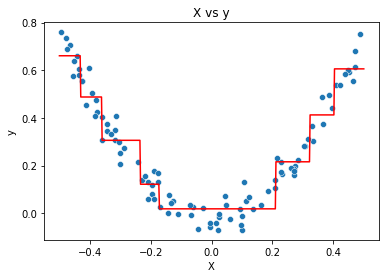

In [136]:
sns.scatterplot(df['X'],df['y'])
sns.lineplot(x=X_test_plot,y=y_pred_plot,color='red');
plt.title('X vs y');

In [137]:
df['pred2'] = mean_y + tree1.predict(df[['X']])
df.head()

,X,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018320
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018320
4,-0.343981,0.343986,0.265458,0.078528,0.305965


#### Repeat Step 2 for 2nd Decision Tree (M = 2)

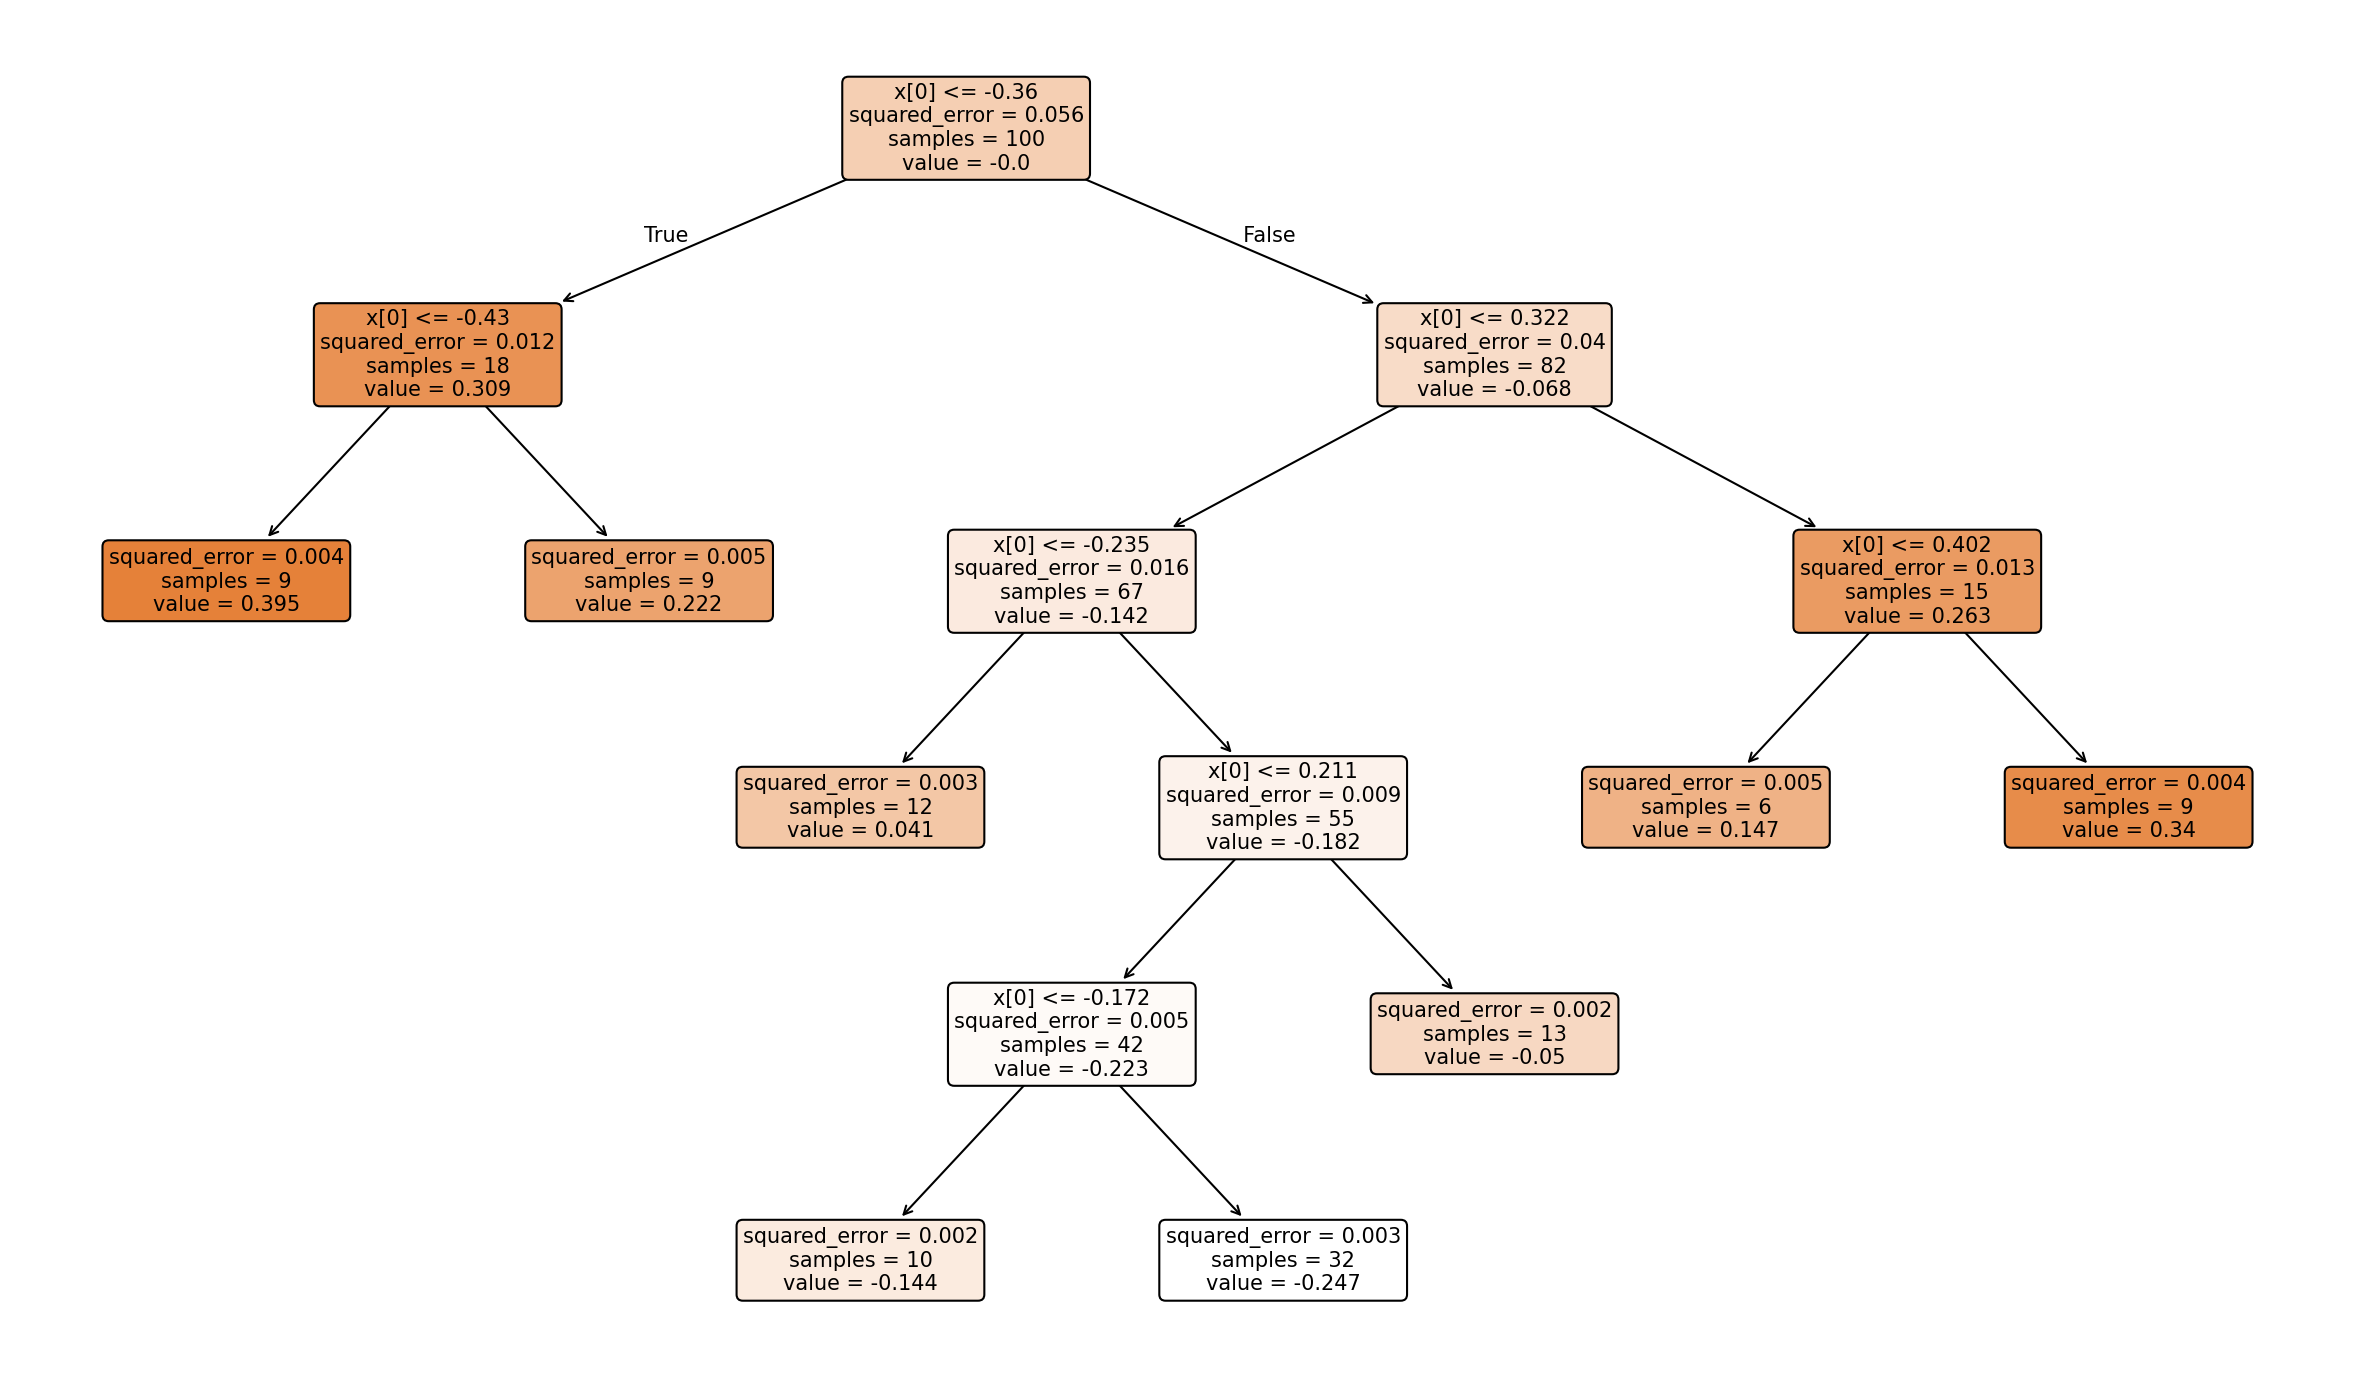

,X,y,pred1,res1,pred2,res2,pred3
0,-0.125460,0.051573,0.265458,-0.213885,0.018320,0.033253,0.014321
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404,0.597523
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732,0.207423
3,0.098658,-0.070178,0.265458,-0.335636,0.018320,-0.088497,-0.019811
4,-0.343981,0.343986,0.265458,0.078528,0.305965,0.038021,0.301966


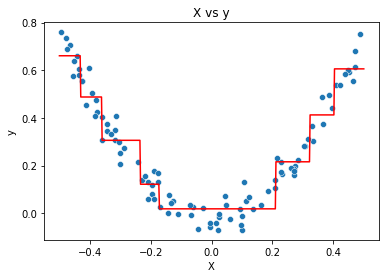

In [138]:
df['res2']= df['y'] - df['pred2'] # Step 2(a)

tree2 = DecisionTreeRegressor(max_leaf_nodes=8,random_state=42)  # Step 2(b)
tree2.fit(df[['X']],df['res2']) # Step 2(b)
plt.figure(figsize=(20,12),dpi=150)
plot_tree(tree1,filled=True,rounded=True,fontsize=10)
plt.show()

# Plotting graph on testing data
y_pred = mean_y + sum(t.predict(X_test_plot.reshape(-1, 1)) for t in [tree1,tree2])
sns.scatterplot(df['X'],df['y'])
sns.lineplot(x=X_test_plot,y=y_pred_plot,color='red');
plt.title('X vs y');

# Step 2(c)
y_pred = 0.265458 + sum(regressor.predict(df['X'].values.reshape(-1, 1)) for regressor in [tree1,tree2])

# Step 2(c) and (d)
df['pred3'] = mean_y + sum(t.predict(df[['X']]) for t in [tree1,tree2])

df.head()



In [139]:
def gradient_boost(X, y, number, lr,mean_pred, count=1, regs=None, foo=None):

    # 'number' = number of trees to train
    # 'lr' = learning rate
    # mean_pred : the baseline prediction (mean of y_train), fixed across the whole recursion
    # 'count' = keeps track of the current iteration
    # 'regs' = stores all trained regression trees
    # 'foo' = stores the original target values for plotting

    
    if regs is None:
        regs=[]
        
    # Base condition: Stop when the required number of trees have been trained.
    if number == 0:
        return regs

    if count>1:
        residual = y - lr * regs[-1].predict(X)

        # ---------------- Step 2(a): Calculate Residuals ----------------

        # From the second iteration onwards,
        # subtract the latest tree's predictions (scaled by the learning rate)
        # from the previous residuals to obtain the new residuals.
        
    # During the first iteration, there is no previous tree.
    # Store the original target values for plotting later
    # and calculate the initial residuals by subtracting the baseline prediction.
    else:
        foo = y.copy()
        residual = y - mean_pred

    # ---------------- Step 2(b): Train a Regression Tree ----------------

    # Train a regression tree on the current residuals.
    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, residual)

    # Store the trained tree.
    regs.append(tree_reg)

    # ---------------- Step 2(c): Predict using all Trees ----------------

    # Generate smooth x-values for plotting.
    x1 = np.linspace(-0.5, 0.5, 500).reshape(-1,1)

    # Initialize predictions with the baseline prediction.
    y_plot = np.full(x1.shape[0], mean_pred) 
    
    # Each tree predicts corrections (residuals).
    # Multiply each prediction by the learning rate and add it
    # to the baseline prediction.
    
    y_plot = np.full(x1.shape[0], mean_pred)
    for regressor in regs:
        y_plot += lr * regressor.predict(x1)

    # Display the current iteration number.
    print(f"Trained tree {count}, {number - 1} remaining")

    # Plot the boosted prediction curve.
    plt.figure()
    plt.plot(x1[:,0], y_plot, linewidth=2,color='red')

    # Plot the original training data.
    plt.plot(X[:, 0], foo, "b.")
    plt.show()

    # ---------------- Step 2(d): Update the Model ----------------

    # Recursively train the next regression tree using the updated residuals.
    return gradient_boost(
        X,
        residual,
        number - 1,
        lr,
        mean_pred,
        count + 1,
        regs,
        foo=foo
    )

## Model Training using Gradient Boost Function

In [140]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

### Train Test Splitting Before Training

In [141]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

Trained tree 1, 4 remaining


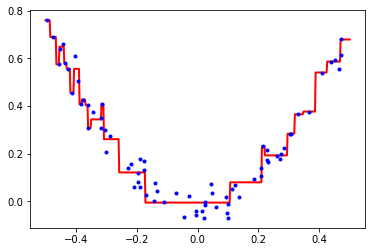

Trained tree 2, 3 remaining


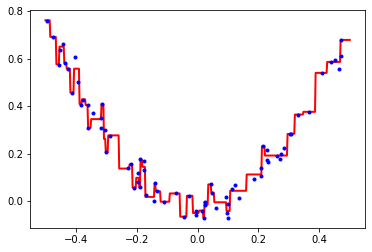

Trained tree 3, 2 remaining


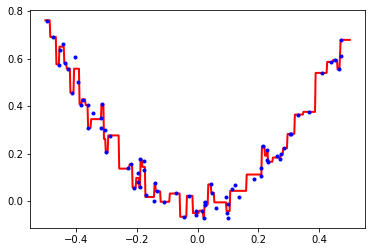

Trained tree 4, 1 remaining


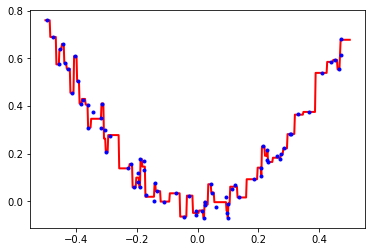

Trained tree 5, 0 remaining


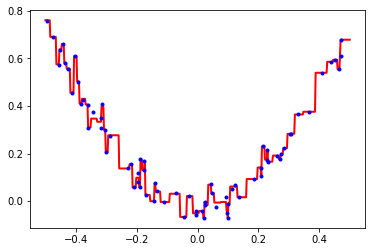

In [142]:
# Model Training on Training Dataset


lr=1
mean_pred=y_train.mean()
regs=gradient_boost(X_train,y_train,5,lr=lr,mean_pred=mean_pred)

### Model Evaluation on Testing Dataset

In [143]:
# Gradient Boosting starts by predicting the mean of the target values.

initial_prediction = mean_pred # base model

y_pred = np.full(len(X_test), initial_prediction) # Creates an array having the same length as the dataset. Initially every prediction is equal to the mean.

for tree in regs:
    y_pred += lr * tree.predict(X_test)
    
    
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Model Performance
------------------------------
Mean Squared Error (MSE): 0.0030
Root Mean Squared Error (RMSE): 0.0547
Mean Absolute Error (MAE): 0.0415
R² Score: 0.9433


## Gradient Boost Regression Implementation using Scikit-learn

In [144]:
from sklearn.ensemble import GradientBoostingRegressor


gb=GradientBoostingRegressor(n_estimators=5,
                             learning_rate=1,
                             max_depth=5,
                             random_state=42
                            )
gb.fit(X_train,y_train)
y_pred = gb.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Model Performance
------------------------------
Mean Squared Error (MSE): 0.0030
Root Mean Squared Error (RMSE): 0.0547
Mean Absolute Error (MAE): 0.0415
R² Score: 0.9433
